In [1]:
# Step 1 : importing importan libraries and Data loading 

import pandas as pd          # Data manipulation and analysis
import numpy as np           # Numerical operations
import matplotlib.pyplot as plt  # Static plotting
import seaborn as sns        # Statistical visualizations (built on matplotlib)
import plotly.express as px  # Interactive visualizations

# Configuring plot style 
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
# Loading the Dataset 
df = pd.read_csv('../data/database.csv')
# Display basic info
print(f" Dataset Shape: {df.shape[0]:,} rows  {df.shape[1]} columns")
print(f"\n Column Names:\n{list(df.columns)}")

 Dataset Shape: 46,185 rows  14 columns

 Column Names:
['Declaration Number', 'Declaration Type', 'Declaration Date', 'State', 'County', 'Disaster Type', 'Disaster Title', 'Start Date', 'End Date', 'Close Date', 'Individual Assistance Program', 'Individuals & Households Program', 'Public Assistance Program', 'Hazard Mitigation Program']


In [ ]:
# df.head() prints first five rows of dataset 
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program
0,DR-1,Disaster,05/02/1953,GA,NaN,Tornado,Tornado,05/02/1953,05/02/1953,06/01/1954,Yes,No,Yes,Yes
1,DR-2,Disaster,05/15/1953,TX,NaN,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01/01/1958,Yes,No,Yes,Yes
2,DR-3,Disaster,05/29/1953,LA,NaN,Flood,Flood,05/29/1953,05/29/1953,02/01/1960,Yes,No,Yes,Yes
3,DR-4,Disaster,06/02/1953,MI,NaN,Tornado,Tornado,06/02/1953,06/02/1953,02/01/1956,Yes,No,Yes,Yes
4,DR-5,Disaster,06/06/1953,MT,NaN,Flood,Floods,06/06/1953,06/06/1953,12/01/1955,Yes,No,Yes,Yes


In [ ]:
df.info() # this will tell us column names and their data types with number of non-null values 

<class 'pandas.DataFrame'>
RangeIndex: 46185 entries, 0 to 46184
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Declaration Number                46185 non-null  str  
 1   Declaration Type                  46185 non-null  str  
 2   Declaration Date                  46185 non-null  str  
 3   State                             46185 non-null  str  
 4   County                            45988 non-null  str  
 5   Disaster Type                     46185 non-null  str  
 6   Disaster Title                    46185 non-null  str  
 7   Start Date                        46185 non-null  str  
 8   End Date                          45843 non-null  str  
 9   Close Date                        35210 non-null  str  
 10  Individual Assistance Program     46185 non-null  str  
 11  Individuals & Households Program  46185 non-null  str  
 12  Public Assistance Program         46185 non

In [ ]:
# checking Missing Values 

missing = df.isnull().sum() # counts number of empty cell each column has 
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("Columns with missing values:")
print(missing_df)
print(f"\n Total rows: {len(df):,}")

Columns with missing values:
            Missing Count  Missing %
Close Date          10975      23.76
End Date              342       0.74
County                197       0.43

 Total rows: 46,185


In [9]:
# converting data columns to datatime 
date_columns = ['Declaration Date', 'Start Date', 'End Date', 'Close Date']

for col in date_columns:
    df[col] = pd.to_datetime(df[col], format='%m/%d/%Y', errors='coerce')

#verifying the conversion 
print("Date columns converted! New data types:")
print(df[date_columns].dtypes)
print(f"\n Date range: {df['Declaration Date'].min().strftime('%Y-%m-%d')} to {df['Declaration Date'].max().strftime('%Y-%m-%d')}")


Date columns converted! New data types:
Declaration Date    datetime64[us]
Start Date          datetime64[us]
End Date            datetime64[us]
Close Date          datetime64[us]
dtype: object

 Date range: 1953-05-02 to 2017-02-14


In [12]:
# extracting usefull features from data 

df['Year'] = df['Declaration Date'].dt.year
df['Month'] = df['Declaration Date'].dt.month
df['Decade'] = (df['Year'] // 10) * 10  # e.g., 1953 -> 1950, 2015 -> 2010

# Duration = End Date - Start Date (in days)
# .dt.days converts the timedelta to a plain number
df['Duration'] = (df['End Date'] - df['Start Date']).dt.days

print("New features created!")
print(f" Year range: {df['Year'].min()} to {df['Year'].max()}")
# print(f" Decades covered: {sorted(df['Decade'].unique())}")
print(f" Duration stats (days):")
print(df['Duration'].describe().to_string())

New features created!
 Year range: 1953 to 2017
 Duration stats (days):
count    45843.000000
mean        25.774578
std         94.965599
min       -340.000000
25%          2.000000
50%         11.000000
75%         33.000000
max       5117.000000


In [13]:
#standardize disaster type categories 
print("Disaster Types and their counts:")
print(df['Disaster Type'].value_counts())
print(f"\n Total unique disaster types: {df['Disaster Type'].nunique()}")

Disaster Types and their counts:
Disaster Type
Storm              16250
Flood               9317
Hurricane           8764
Snow                3565
Fire                2647
Ice                 1970
Tornado             1412
Drought             1292
Winter               301
Other                297
Typhoon              119
Earthquake           105
Volcano               50
Water                 42
Chemical              18
Mud/Landslide         10
Tsunami                9
Dam/Levee Break        6
Human Cause            6
Terrorism              5
Name: count, dtype: int64

 Total unique disaster types: 20


In [15]:
# Handle missing values

df['County'] = df['County'].fillna('Statewide')

# Handle the assistance program columns — fill missing with 'No'
program_cols = ['Individual Assistance Program', 'Individuals & Households Program',
                'Public Assistance Program', 'Hazard Mitigation Program']
for col in program_cols:
    df[col] = df[col].fillna('No')

print(" Missing values handled!")
print(f"\n Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

 Missing values handled!

 Remaining missing values:
End Date        342
Close Date    10975
Duration        342
dtype: int64


In [16]:
# view cleaned dataset
print(" Cleaned dataset summary:")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Date range: {df['Year'].min()} - {df['Year'].max()}")
print(f"   States/Territories: {df['State'].nunique()}")
print(f"   Disaster Types: {df['Disaster Type'].nunique()}")
print(f"\n Final column types:")
print(df.dtypes)

 Cleaned dataset summary:
   Shape: 46,185 rows × 18 columns
   Date range: 1953 - 2017
   States/Territories: 59
   Disaster Types: 20

 Final column types:
Declaration Number                             str
Declaration Type                               str
Declaration Date                    datetime64[us]
State                                          str
County                                         str
Disaster Type                                  str
Disaster Title                                 str
Start Date                          datetime64[us]
End Date                            datetime64[us]
Close Date                          datetime64[us]
Individual Assistance Program                  str
Individuals & Households Program               str
Public Assistance Program                      str
Hazard Mitigation Program                      str
Year                                         int32
Month                                        int32
Decade                    

In [18]:
# Initial exploratory data analysis(EDA)
print("Summary statistics for numerical columns:")
df[['Year', 'Month', 'Duration']].describe().round(2)

Summary statistics for numerical columns:


,Year,Month,Duration
count,46185.00,46185.00,45843.00
mean,1998.36,6.02,25.77
std,13.25,3.17,94.97
min,1953.00,1.00,-340.00
25%,1993.00,3.00,2.00
50%,2003.00,6.00,11.00
75%,2008.00,9.00,33.00
max,2017.00,12.00,5117.00


In [19]:
# top 15 states by number of disaster declarations
state_counts = df.groupby('State')['Declaration Number'].nunique().sort_values(ascending=False)
print(" Top 15 States by Number of Unique Disaster Declarations:")
print(state_counts.head(15).to_string())

 Top 15 States by Number of Unique Disaster Declarations:
State
TX    252
CA    211
OK    159
FL    122
WA     97
NY     93
AL     79
NM     78
LA     76
KY     72
CO     72
AR     70
MS     69
MO     68
WV     67


In [20]:
# declarations by disaster type

type_counts = df['Disaster Type'].value_counts()
print("🌪️ Declarations by Disaster Type:")
print(type_counts.to_string())


🌪️ Declarations by Disaster Type:
Disaster Type
Storm              16250
Flood               9317
Hurricane           8764
Snow                3565
Fire                2647
Ice                 1970
Tornado             1412
Drought             1292
Winter               301
Other                297
Typhoon              119
Earthquake           105
Volcano               50
Water                 42
Chemical              18
Mud/Landslide         10
Tsunami                9
Dam/Levee Break        6
Human Cause            6
Terrorism              5


In [22]:
# declaration per year 
yearly_counts = df.groupby('Year')['Declaration Number'].nunique()
print(f" Declarations per year (first 10 years):")
print(yearly_counts.head(10).to_string())
print(f"\n Year with most declarations: {yearly_counts.idxmax()} ({yearly_counts.max()} declarations)")
print(f" Year with fewest declarations: {yearly_counts.idxmin()} ({yearly_counts.min()} declarations)")

 Declarations per year (first 10 years):
Year
1953    13
1954    17
1955    18
1956    16
1957    16
1958     7
1959     7
1960    12
1961    12
1962    22

 Year with most declarations: 2011 (241 declarations)
 Year with fewest declarations: 1958 (7 declarations)


Yearly Trend Analysis :
 
1. The graph shows the total number of disaster declarations per year.
2. There is a noticeable upward trend, particularly after the 1970s and more prominently after the 1990s.
3. Sudden spikes in certain years may correspond to major natural events or policy-related changes in disaster reporting


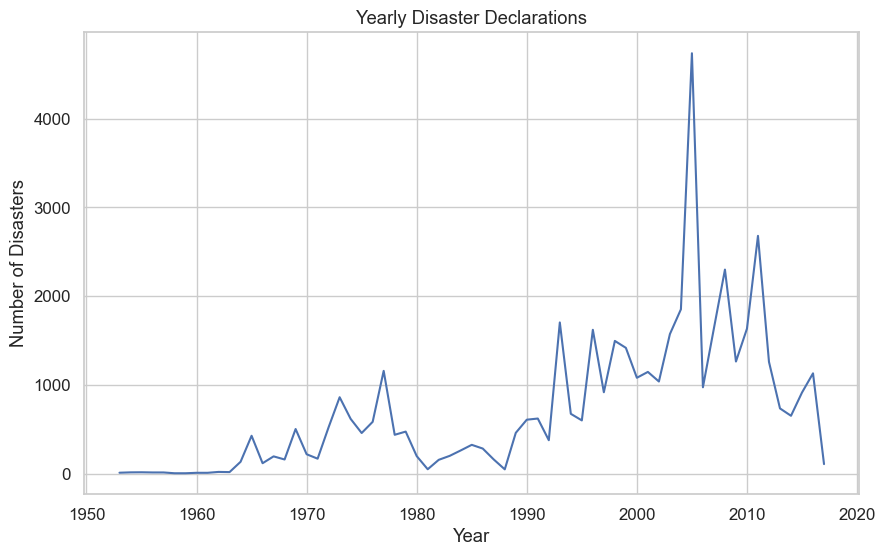

In [23]:
import matplotlib.pyplot as plt

# Group by Year
yearly_counts = df.groupby('Year').size()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(yearly_counts.index, yearly_counts.values)

plt.title("Yearly Disaster Declarations")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.grid(True)

plt.show()

Smoothed Trend Analysis : 

To better understand long-term patterns, a 5-year moving average is applied to smooth short-term fluctuations in yearly disaster counts.

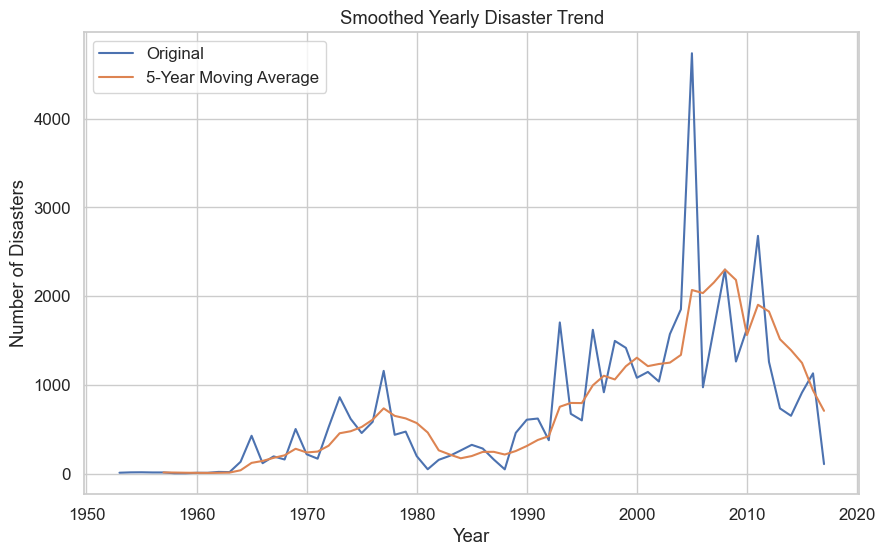

In [24]:
rolling_avg = yearly_counts.rolling(window=5).mean()

plt.figure(figsize=(10,6))
plt.plot(yearly_counts.index, yearly_counts.values, label="Original")
plt.plot(rolling_avg.index, rolling_avg.values, label="5-Year Moving Average")
plt.title("Smoothed Yearly Disaster Trend")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.legend()
plt.grid(True)
plt.show()

1. The rolling average smooths short-term fluctuations in yearly disaster counts.
2. It highlights the long-term increasing trend more clearly.
3. The smoothed curve confirms gradual structural growth in disaster declarations over time.

 Incident Type Trends Over Time:

 1. The graph compares the yearly frequency of the top five disaster types.
2. Storm and hurricane-related disasters appear more frequently compared to other categories.
3. Certain disaster types show noticeable spikes in specific years, possibly due to major natural events.

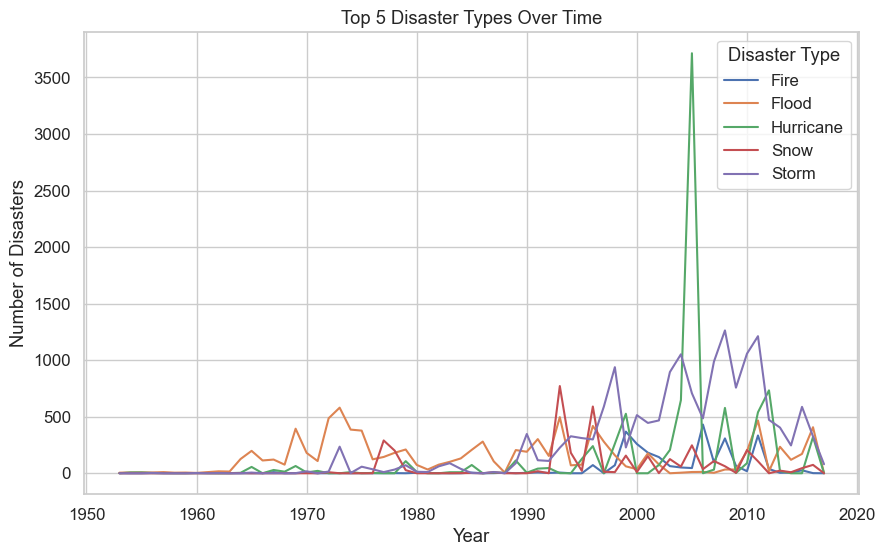

In [25]:
# Get Top 5 Disaster Types
top_types = df['Disaster Type'].value_counts().head(5).index

# Filter only top 5
df_top = df[df['Disaster Type'].isin(top_types)]

# Group by Year and Disaster Type
incident_trend_top = (
    df_top
    .groupby(['Year', 'Disaster Type'])
    .size()
    .unstack(fill_value=0)
)

# Plot
incident_trend_top.plot(figsize=(10,6))

plt.title("Top 5 Disaster Types Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.legend(title="Disaster Type")
plt.grid(True)

plt.show()

Seasonality Analysis (Monthly Trends)

1. The graph shows the number of disaster declarations distributed across .different months.
2. Certain months, especially late summer and early autumn, display higher disaster frequencies.
3. Some early-year months also show moderate activity, possibly due to winter-related disasters.

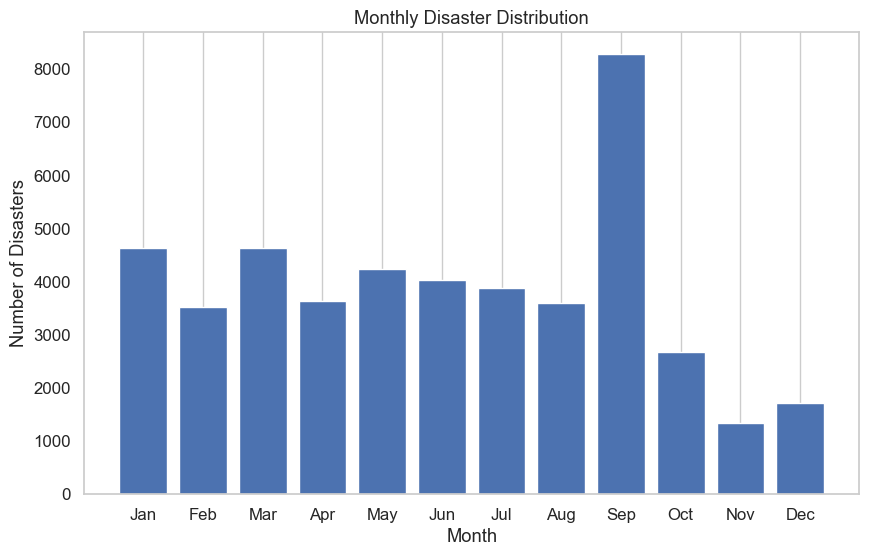

In [26]:
import matplotlib.pyplot as plt

# Group by Month (capital M)
monthly_counts = df.groupby('Month').size()

# Sort months properly (1 to 12)
monthly_counts = monthly_counts.sort_index()

months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(10,6))
plt.bar(months, monthly_counts.values)

plt.title("Monthly Disaster Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Disasters")
plt.grid(axis='y')

plt.show()


Cumulative Disaster Growth Analysis

1. The cumulative graph shows the total number of disaster declarations accumulating over time.
2. The curve becomes steeper in recent decades, indicating a higher frequency of disasters compared to earlier years.
3. The accelerating slope suggests that disaster declarations are increasing at a sustained rate.


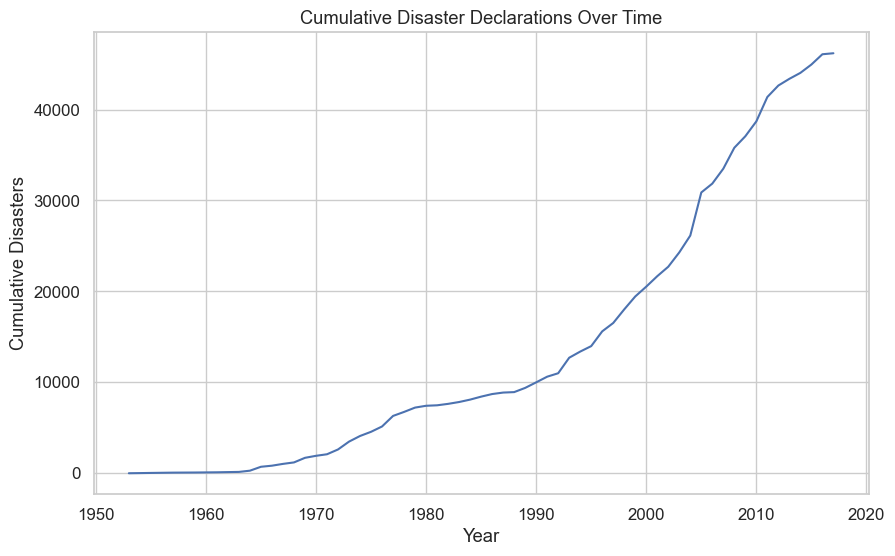

In [27]:
import matplotlib.pyplot as plt

# Create yearly counts (if not already created)
yearly_counts = df.groupby('Year').size().sort_index()

# Cumulative sum
cumulative = yearly_counts.cumsum()

# Plot
plt.figure(figsize=(10,6))
plt.plot(cumulative.index, cumulative.values)

plt.title("Cumulative Disaster Declarations Over Time")
plt.xlabel("Year")
plt.ylabel("Cumulative Disasters")
plt.grid(True)

plt.show()

Peak Year Identification

1. The peak year represents the year with the highest recorded number of disaster declarations.
2. The unusually high value in this year may be associated with significant natural events or multiple large-scale disasters.
3. Identifying the peak year helps highlight extreme periods in disaster history


In [28]:
# Create yearly counts (if not already created)
yearly_counts = df.groupby('Year').size().sort_index()

# Find peak year
peak_year = yearly_counts.idxmax()
peak_value = yearly_counts.max()

print("Peak Year:", peak_year)
print("Maximum Number of Disasters:", peak_value)

Peak Year: 2005
Maximum Number of Disasters: 4736


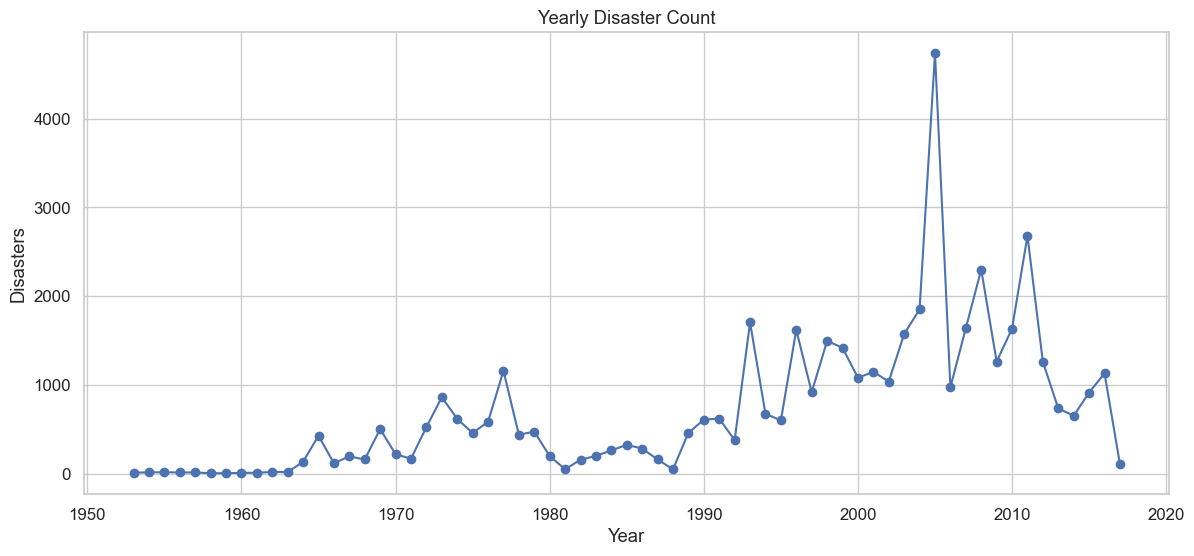

In [29]:
plt.plot(yearly_counts.index, yearly_counts.values, marker='o')
plt.title("Yearly Disaster Count")
plt.xlabel("Year")
plt.ylabel("Disasters")
plt.show()